# Are Label Embeddings Discriminative Enough?
## Probing Semantic Label Similarity as a Source of Fine-Grained Failure in Zero-Shot Intent Detection

**Model**: `all-MiniLM-L6-v2` (sentence-transformers)  
**Dataset**: BANKING77 (12-intent pilot subset)  


In [1]:
# dependencies
!pip install sentence-transformers datasets scipy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('figures', exist_ok=True)


## 1. Configuration 12-Intent Pilot Subset

In [3]:
# 12 intent subset using exact label names from the BANKING77 CSV
# Chosen to span a wide range of semantic similarities

SUBSET_IDS = [
    'card_arrival',
    'card_delivery_estimate',
    'card_linking',
    'card_not_working',
    'declined_card_payment',
    'lost_or_stolen_card',
    'transfer_not_received_by_recipient',
    'transfer_timing',
    'exchange_rate',
    'cash_withdrawal_charge',
    'balance_not_updated_after_bank_transfer',
    'getting_spare_card',
]

# display names (for axis labels)
SHORT_NAMES = [
    'card arrival',
    'card delivery est.',
    'card linking',
    'card not working',
    'declined card payment',
    'lost/stolen card',
    'transfer not received',
    'transfer timing',
    'exchange rate',
    'cash w/d charge',
    'balance not updated',
    'getting spare card',
]

# Names passed to the sentence encoder (spaces, no underscores)
LABEL_TEXTS = [s.replace('_', ' ') for s in SUBSET_IDS]

N = len(SUBSET_IDS)
print(f'{N} intents selected:')
for s in SUBSET_IDS:
    print(f'  - {s}')


12 intents selected:
  - card_arrival
  - card_delivery_estimate
  - card_linking
  - card_not_working
  - declined_card_payment
  - lost_or_stolen_card
  - transfer_not_received_by_recipient
  - transfer_timing
  - exchange_rate
  - cash_withdrawal_charge
  - balance_not_updated_after_bank_transfer
  - getting_spare_card


## Load BANKING77 Dataset

In [4]:
import requests, csv, io

# BANKING77 GIT URL
BASE_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data"

def _load_csv(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return list(csv.DictReader(io.StringIO(r.text)))

print("Downloading BANKING77 train split")
train_rows = _load_csv(f"{BASE_URL}/train.csv")
print("Downloading BANKING77 test split")
test_rows  = _load_csv(f"{BASE_URL}/test.csv")

# Build label index (77 intents, sorted alphabetically)
all_labels = sorted(set(r['category'] for r in train_rows + test_rows))
label2id   = {l: i for i, l in enumerate(all_labels)}

# Convert to flat lists matching the format the rest of the notebook expects
test_texts  = [r['text']                  for r in test_rows]
test_labels = [label2id[r['category']]    for r in test_rows]

# Map SUBSET_IDS to integer label IDs
subset_label_ids = [label2id[s] for s in SUBSET_IDS]


print(f"\nLoaded: {len(train_rows)} train | {len(test_rows)} test | {len(all_labels)} intents")
print(f"Subset label IDs: {subset_label_ids}")



Loaded: 10003 train | 3080 test | 77 intents
Subset label IDs: [12, 13, 14, 15, 26, 42, 66, 67, 33, 20, 6, 40]


## Compute Label Embeddings

In [5]:
from sentence_transformers import SentenceTransformer

print('Loading all-MiniLM-L6-v2')
encoder = SentenceTransformer('all-MiniLM-L6-v2')

# Encode the 12 intent label texts
label_embeddings = encoder.encode(LABEL_TEXTS, normalize_embeddings=True)
print(f'Label embeddings shape: {label_embeddings.shape}')

# Compute full 12x12 cosine similarity matrix
sim_matrix = cosine_similarity(label_embeddings)

# Print the upper-triangle statistics
upper = sim_matrix[np.triu_indices(N, k=1)]
print(f'Label-pair cosine similarity: min={upper.min():.3f}, max={upper.max():.3f}, mean={upper.mean():.3f}')

Loading all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Label embeddings shape: (12, 384)
Label-pair cosine similarity: min=0.016, max=0.713, mean=0.288


## Zero-Shot Pairwise Classification Accuracy

For each label pair (i, j): collect all test utterances belonging to either intent,
classify by nearest label embedding, and record accuracy.

In [6]:
print('Encoding test utterances')
test_embs   = encoder.encode(test_texts, batch_size=128,
                                  normalize_embeddings=True, show_progress_bar=True)

pair_sims, pair_accs, pair_labs = [], [], []
for i in range(N):
    for j in range(i+1, N):
        id_i = subset_label_ids[i]
        id_j = subset_label_ids[j]
        # Collect test samples belonging to either intent
        idx = [k for k, lbl in enumerate(test_labels) if lbl in (id_i, id_j)]
        if len(idx) < 2:
            continue
        embs_ij = test_embs[idx]
        true_ij = np.array([test_labels[k] for k in idx])
        # Two candidate label embeddings
        cand    = np.stack([label_embeddings[i], label_embeddings[j]])
        scores  = embs_ij @ cand.T           # shape: (n_samples, 2)
        pred    = scores.argmax(axis=1)       # 0 = intent i, 1 = intent j
        true    = (true_ij == id_j).astype(int)
        acc     = (pred == true).mean()
        pair_sims.append(sim_matrix[i, j])
        pair_accs.append(acc)
        pair_labs.append((SHORT_NAMES[i], SHORT_NAMES[j]))


pair_sims = np.array(pair_sims)
pair_accs = np.array(pair_accs)

# Statistics
r, _       = stats.pearsonr(pair_sims, pair_accs)
rho, p_rho = stats.spearmanr(pair_sims, pair_accs)
r2         = r ** 2

print(f'\nPairwise results across {len(pair_sims)} label pairs:')
print(f'  Pearson R²          = {r2:.3f}')
print(f'  Spearman ρ          = {rho:.3f}  (p = {p_rho:.4f})')
print(f'  Accuracy range      = {pair_accs.min()*100:.1f}% – {pair_accs.max()*100:.1f}%')
print(f'  Similarity range    = {pair_sims.min():.3f} – {pair_sims.max():.3f}')

# Print the 5 most and least similar pairs
order = np.argsort(pair_sims)[::-1]
print('\nTop 5 most similar pairs (highest confusion risk):')
for k in order[:5]:
    print(f'  {pair_labs[k][0]} / {pair_labs[k][1]}: sim={pair_sims[k]:.3f}, acc={pair_accs[k]*100:.1f}%')
print('\nTop 5 most distinct pairs (lowest confusion risk):')
for k in order[-5:][::-1]:
    print(f'  {pair_labs[k][0]} / {pair_labs[k][1]}: sim={pair_sims[k]:.3f}, acc={pair_accs[k]*100:.1f}%')

Encoding test utterances


Batches:   0%|          | 0/25 [00:00<?, ?it/s]


Pairwise results across 66 label pairs:
  Pearson R²          = 0.464
  Spearman ρ          = -0.773  (p = 0.0000)
  Accuracy range      = 63.7% – 100.0%
  Similarity range    = 0.016 – 0.713

Top 5 most similar pairs (highest confusion risk):
  card arrival / card delivery est.: sim=0.713, acc=63.7%
  lost/stolen card / getting spare card: sim=0.638, acc=96.2%
  card arrival / getting spare card: sim=0.609, acc=93.8%
  card arrival / card linking: sim=0.577, acc=87.5%
  card arrival / card not working: sim=0.554, acc=85.0%

Top 5 most distinct pairs (lowest confusion risk):
  card not working / transfer timing: sim=0.016, acc=100.0%
  declined card payment / transfer timing: sim=0.037, acc=100.0%
  lost/stolen card / exchange rate: sim=0.044, acc=100.0%
  exchange rate / getting spare card: sim=0.060, acc=100.0%
  card not working / exchange rate: sim=0.072, acc=100.0%


## Figure 1 Label Embedding Cosine Similarity Heatmap

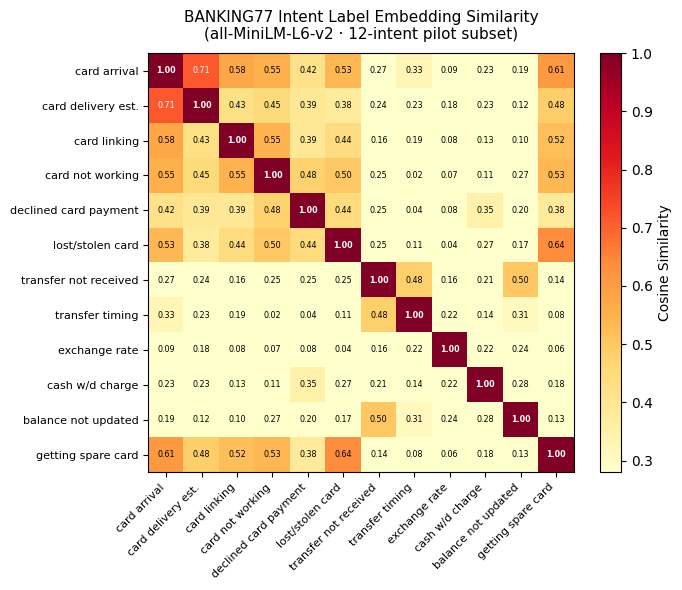

Saved → figures/intent_label_similarity.png


In [7]:
fig1, ax1 = plt.subplots(figsize=(7.0, 6.0))

im = ax1.imshow(sim_matrix, vmin=0.28, vmax=1.0, cmap='YlOrRd', aspect='auto')
cbar = plt.colorbar(im, ax=ax1)
cbar.set_label('Cosine Similarity', fontsize=10)

ax1.set_xticks(range(N))
ax1.set_yticks(range(N))
ax1.set_xticklabels(SHORT_NAMES, rotation=45, ha='right', fontsize=8)
ax1.set_yticklabels(SHORT_NAMES, fontsize=8)

# Annotate each cell with the similarity value
for i in range(N):
    for j in range(N):
        val   = sim_matrix[i, j]
        color = 'white' if val > 0.70 else 'black'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=5.8, color=color, fontweight='bold' if i == j else 'normal')

ax1.set_title(
    'BANKING77 Intent Label Embedding Similarity\n'
    '(all-MiniLM-L6-v2 · 12-intent pilot subset)',
    fontsize=11, pad=10
)

fig1.tight_layout()
fig1.savefig('figures/intent_label_similarity.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved → figures/intent_label_similarity.png')

## Figure 2 Label Similarity vs. Zero-Shot Pairwise Accuracy (Scatter)

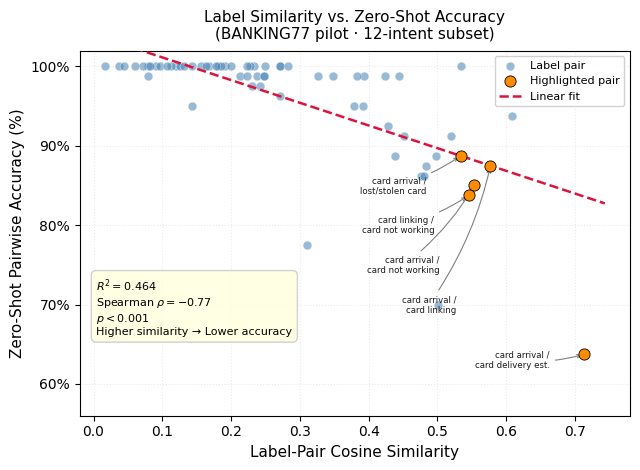

Saved → figures/scatter_similarity_vs_accuracy.png


In [8]:
order = np.argsort(pair_sims)[::-1]
# Pick pairs where similarity is high and accuracy is genuinely low (< 88%)
trend_pairs  = [k for k in order if pair_accs[k] < 0.90 and pair_sims[k] > 0.35]
annotate_idx = trend_pairs[:5]

fig2, ax2 = plt.subplots(figsize=(6.5, 4.8))

# All background points
ax2.scatter(
    pair_sims, pair_accs * 100,
    color='steelblue', alpha=0.55, s=40,
    edgecolors='white', linewidths=0.5, zorder=3, label='Label pair'
)

# Highlighted points
ax2.scatter(
    pair_sims[annotate_idx], pair_accs[annotate_idx] * 100,
    color='darkorange', s=65, zorder=5,
    edgecolors='black', linewidths=0.6, label='Highlighted pair'
)

# Regression line
m_fit, b_fit = np.polyfit(pair_sims, pair_accs * 100, 1)
xs = np.linspace(pair_sims.min() - 0.03, pair_sims.max() + 0.03, 200)
ax2.plot(xs, m_fit * xs + b_fit, color='crimson',
         linewidth=1.8, linestyle='--', zorder=4, label='Linear fit')

# Annotations
ann_sorted   = sorted(annotate_idx, key=lambda k: pair_sims[k])  # left to right
y_positions  = [84.0, 79.0, 74.0, 69.0, 62.0]  # staggered top to bottom

for rank, k in enumerate(ann_sorted):
    ax2.annotate(
        f'{pair_labs[k][0]} /\n{pair_labs[k][1]}',
        xy        = (pair_sims[k], pair_accs[k] * 100),
        xytext    = (pair_sims[k] - 0.05, y_positions[rank]),
        fontsize  = 6.2,
        color     = '#1a1a1a',
        ha        = 'right',
        arrowprops= dict(arrowstyle='->', color='gray', lw=0.8,
                         connectionstyle='arc3,rad=0.1'),
    )

# Stats box
stats_text = (
    f'$R^2 = {r2:.3f}$\n'
    f'Spearman $\\rho = {rho:.2f}$\n'
    f'$p < 0.001$\n'
    f'Higher similarity \u2192 Lower accuracy'
)
ax2.text(
    0.03, 0.38, stats_text,
    transform=ax2.transAxes, ha='left', va='top', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.45', facecolor='lightyellow',
              edgecolor='#cccccc', alpha=0.9)
)

ax2.set_xlabel('Label-Pair Cosine Similarity', fontsize=11)
ax2.set_ylabel('Zero-Shot Pairwise Accuracy (%)', fontsize=11)
ax2.set_title(
    'Label Similarity vs. Zero-Shot Accuracy\n'
    '(BANKING77 pilot \u00b7 12-intent subset)',
    fontsize=11, pad=8
)

# Legends
ax2.legend(fontsize=8, loc='upper right',
           bbox_to_anchor=(1.0, 1.0),
           framealpha=0.9)

ax2.grid(True, alpha=0.25, linestyle=':')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.set_ylim(bottom=56, top=102)
ax2.set_xlim(left=-0.02, right=0.78)

fig2.tight_layout()
fig2.savefig('figures/scatter_similarity_vs_accuracy.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved \u2192 figures/scatter_similarity_vs_accuracy.png')

## Cosine Similarity Values Table

In [9]:
h1, h2, h3 = "Label Pair", "Cos Sim", "Accuracy"
print(f"{h1:<55} {h2:>8} {h3:>9}")
print("-" * 75)

# 5 highlighted pairs
ann_by_sim = sorted(annotate_idx, key=lambda k: pair_sims[k], reverse=True)
for k in ann_by_sim:
    a, b = pair_labs[k]
    print(f"{a} / {b:<35} {pair_sims[k]:>8.2f} {pair_accs[k]*100:>8.1f}%")

# One low-similarity pair as contrast
low_k = int(np.argmin(pair_sims))
a, b = pair_labs[low_k]
print(f"{a} / {b:<35} {pair_sims[low_k]:>8.2f} {pair_accs[low_k]*100:>8.1f}%")

print()

Label Pair                                               Cos Sim  Accuracy
---------------------------------------------------------------------------
card arrival / card delivery est.                      0.71     63.7%
card arrival / card linking                            0.58     87.5%
card arrival / card not working                        0.55     85.0%
card linking / card not working                        0.55     83.8%
card arrival / lost/stolen card                        0.53     88.8%
card not working / transfer timing                         0.02    100.0%

